# 03 - AI4I Robustness and Decision Extension Updated

This notebook extends the evidence generated in Notebook 1 and Notebook 2 by analysing robustness, corruption sensitivity, dimension-level ranking behaviour, and constraint-aware deployment selection. It forms the methodological backbone for answering RQ1, RQ2 and RQ3.

Research contributions:

- **RQ1 - Dimension-level ranking analysis:**  
  Explains *why* deployment-oriented rankings differ from conventional rankings by isolating the influence of each decision dimension.

- **RQ2 - Robustness sensitivity:**  
  Evaluates the stability of the composite corruption-robustness score under:  
  - leave-one-condition-out analysis  
  - random corruption-weight vectors  
  - severity-prefix protocols

- **RQ3 - Deployment decision framework:**  
  Implements constraint-aware selection, Pareto efficiency, TOPSIS compromise ranking, preference sensitivity, and opportunity-cost analysis.

## Interpretation boundaries

- Constraint values are experimental and not industrial requirements.  
- Composite robustness is a secondary summary; condition-level retention remains primary evidence.  
- TOPSIS is used as an adapted min-max-normalised compromise selector.  
- Operational cost is an assumed asymmetric penalty score (FP=1, FN=10), not a monetary estimate.

In [ ]:
# Install required package
!pip -q install numpy pandas matplotlib scipy scikit-learn

In [ ]:
# Import libraries
from pathlib import Path
import itertools
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kendalltau

warnings.filterwarnings("ignore")

In [ ]:
# Paths and schema configuration

# Output directories
BASE = Path("ai4i_ipmef_final_outputs")
OUT = Path("ai4i_decision_extension_outputs")
FIG = OUT / "figures"

for directory in [OUT, FIG]:
    directory.mkdir(parents=True, exist_ok=True)

# Column names used throughout Notebook 3
ROBUSTNESS_COLUMN = "Composite_Corruption_Robustness_Mean"
ROBUSTNESS_STD_COLUMN = "Composite_Corruption_Robustness_Std"
DEPLOYMENT_RANK_COLUMN = "Deployment_Baseline_Rank"
DEPLOYMENT_SCORE_COLUMN = "Deployment_Baseline_Score"
LATENCY_COLUMN = "Single_Sample_Latency_Median_ms"
OPERATIONAL_COLUMN = "Operational_Cost"

FP_PENALTY = 1.0  # false-positive penalty (FN penalty varies later)

# Required Notebook 1 outputs
required_files = {
    "candidate": BASE / "07_candidate_summary.csv",
    "auretc": BASE / "04_condition_auretc_by_seed.csv",
    "robustness_by_level": BASE / "03_robustness_by_level.csv",
    "rq1": BASE / "08_rq1_conventional_vs_deployment_ranking.csv",
    "clean": BASE / "01_clean_candidate_results.csv",
}

# Check for missing files
missing_files = [
    str(path)
    for path
    in required_files.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required Notebook 1 outputs were not found:\n" + "\n".join(missing_files))

# Load datasets
candidate = pd.read_csv(required_files["candidate"])
auretc = pd.read_csv(required_files["auretc"])
robustness_by_level = pd.read_csv(required_files["robustness_by_level"])
rq1 = pd.read_csv(required_files["rq1"])
clean = pd.read_csv(required_files["clean"])

# Schema validation - ensure required columns exist
required_columns = {
    "candidate": [
        "Variant",
        "F1",
        "PR_AUC",
        "Recall",
        "Brier",
        "ECE",
        "Model_Size_MB",
        ROBUSTNESS_COLUMN,
        LATENCY_COLUMN,
        OPERATIONAL_COLUMN,
    ],
    "rq1": [
        "Variant",
        "Conventional_Rank",
        DEPLOYMENT_RANK_COLUMN,
        "Rank_Change_Deployment_Minus_Conventional",
    ],
    "auretc": [
        "Seed",
        "Variant",
        "Condition",
        "F1_AURetC",
        "Worst_F1_Retention",
    ],
    "robustness_by_level": [
        "Seed",
        "Variant",
        "Condition",
        "Level",
        "F1_Retention",
    ],
    "clean": [
        "Seed",
        "Variant",
        "FP",
        "FN",
    ],
}

for dataset_name, columns in required_columns.items():
    dataframe = {
        "candidate": candidate,
        "rq1": rq1,
        "auretc": auretc,
        "robustness_by_level": robustness_by_level,
        "clean": clean,
    }[dataset_name]

    missing = [column for column in columns if column not in dataframe.columns]

    if missing:
        raise KeyError(
            f"{dataset_name} is missing required columns: "
            + ", ".join(missing)
        )

# Basic diagnostics
print("Candidate rows:", len(candidate))
print("AURetC rows:", len(auretc))
print("Robustness-level rows:", len(robustness_by_level))
print("Clean result rows:", len(clean))

display(candidate.head())

Candidate rows: 18
AURetC rows: 1440
Robustness-level rows: 5760
Clean result rows: 360


,Variant,Model,Strategy,Calibration,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,...,Latency_Per_Sample_Median_ms,Single_Sample_Latency_Median_ms,Single_Sample_Latency_P95_ms,Throughput_Samples_Per_Second,Model_Size_MB,Composite_Corruption_Robustness_Mean,Composite_Corruption_Robustness_Std,Composite_PR_AUC_Robustness_Mean,Mean_Cost_Inflation_AUC,Worst_Condition_Retention_Mean
0,Random Forest | class_weight | isotonic,Random Forest,class_weight,isotonic,0.958100,0.455448,0.847059,0.586499,0.960643,0.670253,...,0.037325,47.453592,52.793462,27001.819201,3.081341,0.793601,0.022469,0.766562,1.617598,0.451700
1,Random Forest | class_weight | none,Random Forest,class_weight,none,0.957967,0.454680,0.845098,0.585199,0.968454,0.720925,...,0.038433,47.495470,52.911514,26155.983523,3.080695,0.795419,0.022237,0.787648,1.607472,0.452850
2,Random Forest | class_weight | platt,Random Forest,class_weight,platt,0.957867,0.453986,0.846078,0.584962,0.968453,0.720925,...,0.038437,47.623069,52.455300,26144.829050,3.081239,0.794893,0.021694,0.787646,1.608879,0.452254
3,Random Forest | none | isotonic,Random Forest,none,isotonic,0.968800,0.553484,0.812745,0.648116,0.964488,0.724874,...,0.037790,48.521867,51.829886,26658.088762,2.571285,0.773891,0.020946,0.707748,1.639891,0.382504
4,Random Forest | none | none,Random Forest,none,none,0.969600,0.560933,0.807843,0.651984,0.970135,0.772168,...,0.039682,50.180797,58.211383,25529.416275,2.570640,0.772448,0.018979,0.734629,1.631359,0.381079


## RQ2 - Leave-one-corruption-condition-out analysis

This section evaluates whether the adapted composite corruption‑robustness score is stable when any single corruption condition is removed from the protocol. This is important because:

- The composite robustness score is a *secondary* summary; condition‑level retention remains the primary evidence.
- If the robustness winner changes dramatically when one condition is omitted, the protocol may be overly sensitive to that condition.
- Rank stability across omitted conditions provides evidence of protocol robustness.

The analysis computes:

- Full-protocol composite scores (all conditions).
- Reduced composite scores (all except one condition).
- Rank correlations (Spearman, Kendall) between full and reduced scores.
- Whether the robustness winner changes when a condition is omitted.

This forms the first part of RQ2.

Purpose:
 - Test whether the composite corruption‑robustness score depends heavily on any single corruption condition.

Method:
- Compute full-protocol composite score (mean across all conditions).
- For each omitted condition:
     - Recompute composite score without that condition.      
     - Compare rankings using Spearman and Kendall correlations.
     - Check whether the robustness winner changes.


In [ ]:
# Mean robustness per (Variant, Condition)
condition_mean = (
    auretc
    .groupby(["Variant", "Condition"], as_index=False)
    .agg(
        F1_AURetC_Mean=("F1_AURetC", "mean"),
        Worst_F1_Retention_Mean=("Worst_F1_Retention", "mean"),
    )
)

# Pivot to Variant × Condition matrix
condition_wide = (
    condition_mean
    .pivot(
        index="Variant",
        columns="Condition",
        values="F1_AURetC_Mean",
    )
)

# Full-protocol composite score (mean across all conditions)
full_protocol_score = condition_wide.mean(axis=1)

# Identify full-protocol winner
full_protocol_winner = full_protocol_score.idxmax()

leave_one_out_rows = []
leave_one_out_score_rows = []

# Leave-one-condition-out loop
for omitted_condition in condition_wide.columns:

    # Reduced composite score (omit one condition)
    reduced_scores = (
        condition_wide
        .drop(columns=[omitted_condition])
        .mean(axis=1)
    )

    # Rank correlations
    spearman_rho, spearman_p = spearmanr(full_protocol_score, reduced_scores)

    full_ranks = full_protocol_score.rank(ascending=False, method="average")
    reduced_ranks = reduced_scores.rank(ascending=False, method="average")

    kendall_tau, kendall_p = kendalltau(full_ranks, reduced_ranks)

    # Reduced winner
    reduced_winner = reduced_scores.idxmax()

    # Store summary row
    leave_one_out_rows.append({
        "Omitted_Condition": omitted_condition,
        "Full_Protocol_Winner": full_protocol_winner,
        "Reduced_Protocol_Winner": reduced_winner,
        "Winner_Changed": (reduced_winner != full_protocol_winner),
        "Spearman_vs_Full": float(spearman_rho),
        "Spearman_p": float(spearman_p),
        "Kendall_vs_Full": float(kendall_tau),
        "Kendall_p": float(kendall_p),
        "Full_Winner_Score": float(full_protocol_score[full_protocol_winner]),
        "Reduced_Winner_Score": float(reduced_scores[reduced_winner]),
    })

    # Store per-variant reduced scores
    for variant, score in reduced_scores.items():
        leave_one_out_score_rows.append({
            "Omitted_Condition": omitted_condition,
            "Variant": variant,
            "Reduced_Composite_Score": float(score),
        })

# Convert to DataFrames
leave_one_out_df = pd.DataFrame(leave_one_out_rows)
leave_one_out_scores_df = pd.DataFrame(leave_one_out_score_rows)

# Save outputs
leave_one_out_df.to_csv(OUT / "01_leave_one_condition_out_summary.csv", index=False)
leave_one_out_scores_df.to_csv(OUT / "01b_leave_one_condition_out_scores.csv", index=False)

# Display summary
display(leave_one_out_df)

,Omitted_Condition,Full_Protocol_Winner,Reduced_Protocol_Winner,Winner_Changed,Spearman_vs_Full,Spearman_p,Kendall_vs_Full,Kendall_p,Full_Winner_Score,Reduced_Winner_Score
0,Gaussian Noise,Random Forest | smote | isotonic,Random Forest | smote | isotonic,False,0.944272,3.923997e-09,0.869281,2.158259e-09,0.811797,0.796223
1,Missing Values MCAR,Random Forest | smote | isotonic,Random Forest | smote | platt,True,0.859649,4.827997e-06,0.738562,2.521580e-06,0.811797,0.776306
2,Outliers,Random Forest | smote | isotonic,Random Forest | smote | isotonic,False,0.902993,2.897516e-07,0.777778,4.360978e-07,0.811797,0.846314
3,Static Sensor Offset,Random Forest | smote | isotonic,Random Forest | smote | isotonic,False,0.886481,9.656766e-07,0.790850,2.294912e-07,0.811797,0.828524


## RQ2 - Corruption-weight sensitivity

This section evaluates how sensitive the composite corruption‑robustness winner is to changes in the importance assigned to each corruption condition.

The full protocol uses **equal weights** across corruption conditions. However, real deployments may implicitly prioritise certain corruption types more than others. To test robustness under alternative weighting schemes:

- 5,000 random weight vectors are sampled from a **Dirichlet distribution**, ensuring all weights are non‑negative and sum to 1.
- Each weight vector represents a hypothetical scenario where corruption conditions have different importance.
- For each weight vector:
  - A weighted composite robustness score is computed for every variant.
  - The winner and runner‑up are recorded.
  - The score margin is computed.
- The frequency with which each variant becomes the winner is summarised.

This analysis answers whether the robustness winner is stable under non‑uniform corruption importance.

Purpose:
- Test whether the robustness winner changes when corruption conditions are assigned random non-uniform weights.

Method:
- Sample 5,000 Dirichlet weight vectors (non‑negative, sum to 1).
- Compute weighted composite robustness scores for each variant.
- Record winner frequency and score margins.

,Variant,Selection_Frequency
0,Random Forest | smote | isotonic,0.8556
1,Random Forest | smote | platt,0.1444


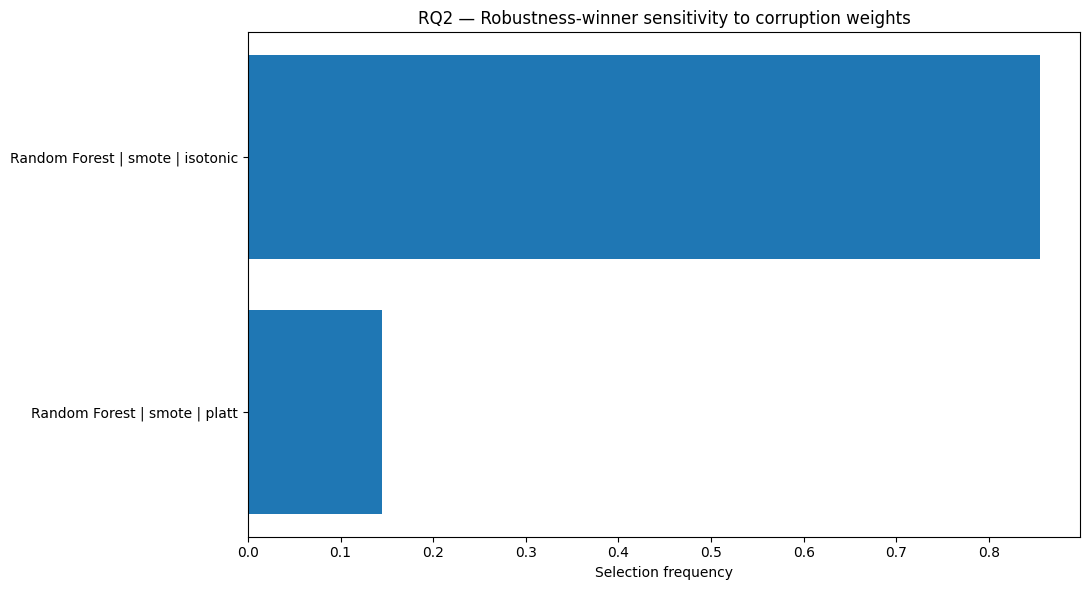

In [ ]:
# Random generator for reproducibility
rng = np.random.default_rng(20260803)

# List of corruption conditions
conditions = list(condition_wide.columns)

# Sample 5,000 Dirichlet weight vectors
weight_samples = rng.dirichlet(
    np.ones(len(conditions)),
    size=5000,
)

# Convert condition matrix to numpy for fast multiplication
condition_matrix = condition_wide.to_numpy(dtype=float)

# Variant names (row index)
variant_names = condition_wide.index.to_numpy()

selection_rows = []

# Compute weighted robustness scores for each weight vector
for sample_index, weights in enumerate(weight_samples):

    # Weighted composite score: matrix multiplication
    scores = condition_matrix @ weights

    # Order variants by score (descending)
    order = np.argsort(scores)[::-1]

    winner_index = order[0]
    runner_up_index = order[1]

    row = {
        "Sample": sample_index,
        "Winner": variant_names[winner_index],
        "Winner_Score": float(scores[winner_index]),
        "Runner_Up": variant_names[runner_up_index],
        "Runner_Up_Score": float(scores[runner_up_index]),
        "Score_Margin": float(scores[winner_index] - scores[runner_up_index]),
    }

    # Store weights for interpretability
    for index, condition in enumerate(conditions):
        row[f"Weight_{condition}"] = float(weights[index])

    selection_rows.append(row)

# Convert to DataFrame
weight_sensitivity_samples = pd.DataFrame(selection_rows)

# Winner frequency across 5,000 samples
weight_selection_frequency = (
    weight_sensitivity_samples["Winner"]
    .value_counts(normalize=True)
    .rename_axis("Variant")
    .reset_index(name="Selection_Frequency")
)

# Save outputs
weight_sensitivity_samples.to_csv(
    OUT / "02_corruption_weight_samples.csv",
    index=False,
)

weight_selection_frequency.to_csv(
    OUT / "02b_corruption_weight_selection_frequency.csv",
    index=False,
)

# Display top 10 most frequently selected variants
display(weight_selection_frequency.head(10))

# Plot winner frequency (top 10)
plt.figure(figsize=(11, 6))

plot_frequency = weight_selection_frequency.head(10)

plt.barh(
    plot_frequency["Variant"][::-1],
    plot_frequency["Selection_Frequency"][::-1],
)

plt.xlabel("Selection frequency")
plt.title("RQ2 — Robustness‑winner sensitivity to corruption weights")
plt.tight_layout()

plt.savefig(
    FIG / "rq2_corruption_weight_sensitivity.png",
    dpi=300,
)

plt.show()

## RQ2 — Severity‑Prefix Sensitivity

This section evaluates whether the robustness ranking is sensitive to the *severity range* used in the corruption protocol.

The original protocol uses all available severity levels for each corruption condition. However, deployments may only experience mild or moderate corruption, or may prioritise early‑severity behaviour.

To test sensitivity:

1. For each corruption condition:
   - progressively include only the first *k* severity levels (k = 2 … max).
   - normalise each prefix to its own maximum severity.
   - compute the trapezoid area (AURetC) for each seed.
   - compute mean and standard deviation across seeds.

2. For each prefix:
   - identify the robustness winner and runner‑up.
   - compute score margins.

This analysis answers whether robustness winners remain stable when the severity protocol is shortened.

Purpose:
- Evaluate whether robustness rankings change when the corruption protocol is truncated to shorter severity ranges.

Method:
- For each corruption condition:
  - progressively include only the first k severity levels.
  -  normalise severity axis to the maximum included level.
  -  compute trapezoid area (AURetC) for each seed.
  - compute mean and std across seeds.
- Identify winner stability across severity-prefix protocols.

In [ ]:
# Helper: compute normalised prefix area
def normalised_prefix_area(group):
    """
    Compute trapezoid area for a severity prefix:
      • Severity axis normalised to [0, 1].
      • F1 retention curve anchored at 1.0 for severity = 0.
    """
    group = group.sort_values("Level")

    maximum_level = float(group["Level"].max())

    # Normalised severity axis (0 to 1)
    x_values = np.r_[0.0, group["Level"].to_numpy() / maximum_level]

    # F1 retention values (anchor at 1.0)
    y_values = np.r_[1.0, group["F1_Retention"].to_numpy()]

    # Trapezoid area
    return float(np.trapezoid(y_values, x_values))

severity_rows = []

# Compute severity-prefix AURetC for each (Variant, Condition)
for (variant, condition), group in robustness_by_level.groupby(["Variant", "Condition"]):

    available_levels = sorted(group["Level"].unique())

    # Prefix lengths: 2 levels up to full protocol
    for level_count in range(2, len(available_levels) + 1):

        selected_levels = available_levels[:level_count]
        selected_group = group[group["Level"].isin(selected_levels)]

        seed_areas = []

        # Compute prefix area per seed
        for seed, seed_group in selected_group.groupby("Seed"):

            seed_level_mean = (
                seed_group
                .groupby("Level", as_index=False)
                .agg(F1_Retention=("F1_Retention", "mean"))
            )

            seed_areas.append(normalised_prefix_area(seed_level_mean))

        severity_rows.append({
            "Variant": variant,
            "Condition": condition,
            "N_Levels": level_count,
            "Maximum_Included_Severity": selected_levels[-1],
            "Normalised_Prefix_AURetC_Mean": float(np.mean(seed_areas)),
            "Normalised_Prefix_AURetC_Std": float(np.std(seed_areas, ddof=1)),
        })

# Convert to DataFrame
severity_sensitivity = pd.DataFrame(severity_rows)

# Save output
severity_sensitivity.to_csv(
    OUT / "03_severity_sensitivity.csv",
    index=False,
)

display(severity_sensitivity.head())

,Variant,Condition,N_Levels,Maximum_Included_Severity,Normalised_Prefix_AURetC_Mean,Normalised_Prefix_AURetC_Std
0,Random Forest | class_weight | isotonic,Gaussian Noise,2,0.1,0.954702,0.021006
1,Random Forest | class_weight | isotonic,Gaussian Noise,3,0.2,0.902789,0.027842
2,Random Forest | class_weight | isotonic,Gaussian Noise,4,0.3,0.849096,0.029915
3,Random Forest | class_weight | isotonic,Missing Values MCAR,2,0.1,0.974379,0.014228
4,Random Forest | class_weight | isotonic,Missing Values MCAR,3,0.2,0.942705,0.024485


In [ ]:
# Winner stability across severity-prefix protocols
severity_winner_rows = []

for (condition, level_count, maximum_severity), group in severity_sensitivity.groupby(
    ["Condition", "N_Levels", "Maximum_Included_Severity"]
):

    ordered = group.sort_values(
        "Normalised_Prefix_AURetC_Mean",
        ascending=False,
    )

    winner = ordered.iloc[0]
    runner_up = ordered.iloc[1]

    severity_winner_rows.append({
        "Condition": condition,
        "N_Levels": level_count,
        "Maximum_Included_Severity": maximum_severity,
        "Winner": winner["Variant"],
        "Winner_Score": winner["Normalised_Prefix_AURetC_Mean"],
        "Runner_Up": runner_up["Variant"],
        "Runner_Up_Score": runner_up["Normalised_Prefix_AURetC_Mean"],
        "Score_Margin": (
            winner["Normalised_Prefix_AURetC_Mean"]
            - runner_up["Normalised_Prefix_AURetC_Mean"]
        ),
    })

severity_winners = pd.DataFrame(severity_winner_rows)

severity_winners.to_csv(
    OUT / "03b_severity_winner_stability.csv",
    index=False,
)

display(severity_winners)

,Condition,N_Levels,Maximum_Included_Severity,Winner,Winner_Score,Runner_Up,Runner_Up_Score,Score_Margin
0,Gaussian Noise,2,0.10,XGBoost | class_weight | isotonic,0.963934,XGBoost | class_weight | none,0.963501,0.000433
1,Gaussian Noise,3,0.20,Random Forest | smote | platt,0.907479,Random Forest | smote | isotonic,0.907197,0.000281
2,Gaussian Noise,4,0.30,Random Forest | smote | isotonic,0.858519,Random Forest | smote | none,0.858082,0.000438
3,Missing Values MCAR,2,0.10,Random Forest | smote | isotonic,0.978024,Random Forest | smote | none,0.977722,0.000302
4,Missing Values MCAR,3,0.20,Random Forest | smote | isotonic,0.948375,Random Forest | smote | none,0.947444,0.000931
5,Missing Values MCAR,4,0.30,Random Forest | smote | isotonic,0.918808,Random Forest | smote | none,0.917796,0.001012
6,Outliers,2,0.03,Random Forest | smote | platt,0.885535,Random Forest | smote | isotonic,0.881941,0.003594
7,Outliers,3,0.05,Random Forest | smote | platt,0.825287,Random Forest | smote | none,0.820546,0.004741
8,Outliers,4,0.10,Random Forest | smote | platt,0.714744,Random Forest | smote | none,0.708739,0.006005
9,Static Sensor Offset,2,0.10,XGBoost | class_weight | platt,0.916540,XGBoost | class_weight | isotonic,0.916306,0.000234


## RQ1 - Dimension‑Level Rank Analysis

This section explains *why* deployment‑oriented rankings differ from conventional rankings.

The deployment baseline score is constructed from five decision dimensions:

1. **Predictive** — F1 and PR‑AUC  
2. **Robustness** — Composite corruption‑robustness  
3. **Reliability** — Brier + ECE  
4. **Efficiency** — Latency + model size  
5. **Operational** — Operational penalty (FP=1, FN=10)

Each dimension is min‑max normalised so that:
- higher is better for benefit metrics (F1, PR‑AUC, robustness)
- lower is better for cost metrics (latency, model size, Brier, ECE, operational cost)

The deployment baseline score is the mean of the five dimensions.

To understand dimension influence:

- The full score is computed using all five dimensions.
- Then each dimension is omitted one at a time.
- Rank changes are recorded.
- Summary statistics quantify how strongly each dimension affects ranking.

This analysis answers RQ1 by identifying which dimensions drive deployment‑oriented rank changes.


In [ ]:
# Min‑max normalisation helpers
def minmax_benefit(series):
    """
    Normalise benefit metrics:
      higher values → better → closer to 1.
    """
    series = pd.Series(series, dtype=float)
    minimum = series.min()
    maximum = series.max()

    if np.isclose(minimum, maximum):
        return pd.Series(np.ones(len(series)), index=series.index)

    return (series - minimum) / (maximum - minimum)


def minmax_cost(series):
    """
    Normalise cost metrics:
      lower values → better → closer to 1.
    """
    return 1.0 - minmax_benefit(series)

# Construct deployment‑oriented decision dimensions
rank_analysis = candidate.copy()

# Predictive dimension: F1 + PR‑AUC
rank_analysis["Predictive"] = (
    minmax_benefit(rank_analysis["F1"])
    + minmax_benefit(rank_analysis["PR_AUC"])
) / 2

# Robustness dimension
rank_analysis["Robustness"] = minmax_benefit(rank_analysis[ROBUSTNESS_COLUMN])

# Reliability dimension: Brier + ECE (both cost metrics)
rank_analysis["Reliability"] = (
    minmax_cost(rank_analysis["Brier"])
    + minmax_cost(rank_analysis["ECE"])
) / 2

# Efficiency dimension: latency + model size (both cost metrics)
rank_analysis["Efficiency"] = (
    minmax_cost(rank_analysis[LATENCY_COLUMN])
    + minmax_cost(rank_analysis["Model_Size_MB"])
) / 2

# Operational dimension: operational penalty (cost metric)
rank_analysis["Operational"] = minmax_cost(rank_analysis[OPERATIONAL_COLUMN])

# List of decision dimensions
decision_dimensions = [
    "Predictive",
    "Robustness",
    "Reliability",
    "Efficiency",
    "Operational",
]

# Full deployment baseline score and rank
rank_analysis["Full_Deployment_Baseline_Score"] = rank_analysis[decision_dimensions].mean(axis=1)

rank_analysis["Full_Deployment_Baseline_Rank"] = (
    rank_analysis["Full_Deployment_Baseline_Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Leave‑one‑dimension‑out analysis
dimension_ablation_rows = []

for omitted_dimension in decision_dimensions:

    retained_dimensions = [
        dim for dim in decision_dimensions
        if dim != omitted_dimension
    ]

    # Reduced score using retained dimensions
    reduced_score = rank_analysis[retained_dimensions].mean(axis=1)

    # Reduced rank
    reduced_rank = (
        reduced_score
        .rank(ascending=False, method="min")
        .astype(int)
    )

    # Store per‑variant results
    for index, row in rank_analysis.iterrows():
        dimension_ablation_rows.append({
            "Variant": row["Variant"],
            "Omitted_Dimension": omitted_dimension,
            "Full_Rank": int(row["Full_Deployment_Baseline_Rank"]),
            "Reduced_Rank": int(reduced_rank.loc[index]),
            "Rank_Change_After_Omission": int(
                reduced_rank.loc[index] - row["Full_Deployment_Baseline_Rank"]
            ),
            "Full_Score": float(row["Full_Deployment_Baseline_Score"]),
            "Reduced_Score": float(reduced_score.loc[index]),
        })

dimension_ablation_df = pd.DataFrame(dimension_ablation_rows)

# Merge conventional ranking comparison (from Notebook 1)
rank_analysis = rank_analysis.merge(
    rq1[
        [
            "Variant",
            "Conventional_Rank",
            DEPLOYMENT_RANK_COLUMN,
            "Rank_Change_Deployment_Minus_Conventional",
        ]
    ],
    on="Variant",
    how="left",
)

# Save outputs
rank_analysis.to_csv(
    OUT / "04_rq1_dimension_scores.csv",
    index=False,
)

dimension_ablation_df.to_csv(
    OUT / "04b_rq1_leave_one_dimension_out.csv",
    index=False,
)

# Display sorted deployment ranking
display(
    rank_analysis.sort_values(DEPLOYMENT_RANK_COLUMN)[
        [
            "Variant",
            "Conventional_Rank",
            DEPLOYMENT_RANK_COLUMN,
            "Rank_Change_Deployment_Minus_Conventional",
            *decision_dimensions,
        ]
    ]
)

,Variant,Conventional_Rank,Deployment_Baseline_Rank,Rank_Change_Deployment_Minus_Conventional,Predictive,Robustness,Reliability,Efficiency,Operational
14,XGBoost | none | platt,1,1,0,1.000000,0.116645,0.991261,0.993222,0.955039
13,XGBoost | none | none,2,2,0,0.995521,0.134343,0.996479,0.992311,0.922481
12,XGBoost | none | isotonic,5,3,-2,0.860052,0.108467,0.990276,0.997990,1.000000
11,XGBoost | class_weight | platt,6,4,-2,0.823603,0.325331,0.954829,0.948669,0.668217
9,XGBoost | class_weight | isotonic,9,5,-4,0.695900,0.308091,0.961356,0.982785,0.677519
10,XGBoost | class_weight | none,4,6,2,0.839860,0.299103,0.628361,0.980588,0.674419
17,XGBoost | smote | platt,3,7,4,0.868316,0.000000,0.945384,0.967322,0.314729
15,XGBoost | smote | isotonic,11,8,-3,0.654205,0.128571,0.958223,0.969711,0.229457
2,Random Forest | class_weight | platt,14,9,-5,0.390446,0.636050,0.825319,0.356777,0.618605
5,Random Forest | none | platt,10,10,0,0.790111,0.135205,0.879429,0.384664,0.632558


In [ ]:
# Summarise dimension influence on ranking
dimension_influence_summary = (
    dimension_ablation_df
    .groupby("Omitted_Dimension", as_index=False)
    .agg(
        Mean_Absolute_Rank_Change=(
            "Rank_Change_After_Omission",
            lambda values: float(np.mean(np.abs(values))),
        ),
        Maximum_Absolute_Rank_Change=(
            "Rank_Change_After_Omission",
            lambda values: int(np.max(np.abs(values))),
        ),
        Number_of_Changed_Ranks=(
            "Rank_Change_After_Omission",
            lambda values: int(np.sum(values != 0)),
        ),
    )
    .sort_values("Mean_Absolute_Rank_Change", ascending=False)
)

dimension_influence_summary.to_csv(
    OUT / "04c_rq1_dimension_influence_summary.csv",
    index=False,
)

display(dimension_influence_summary)

,Omitted_Dimension,Mean_Absolute_Rank_Change,Maximum_Absolute_Rank_Change,Number_of_Changed_Ranks
3,Reliability,1.777778,7,14
0,Efficiency,1.666667,7,12
2,Predictive,1.555556,6,14
1,Operational,0.666667,2,10
4,Robustness,0.555556,3,7


## RQ3 — Constraint‑Aware Pareto & TOPSIS Selection

This section implements the full deployment‑oriented decision sequence:

1. **Constraint filtering**  
   Experimental constraints are applied to remove candidates that fail minimum acceptable levels of recall, robustness, latency, and reliability.  
   These constraints are *not* industrial requirements — they are experimental parameters chosen from observed ranges.

2. **Pareto efficiency**  
   Among feasible candidates, a Pareto front is computed using four deployment objectives:
   - F1 (maximise)
   - Composite corruption‑robustness (maximise)
   - Operational cost (minimise)
   - Single‑sample latency (minimise)

   A candidate is Pareto‑efficient if no other candidate is strictly better in at least one objective and no worse in all others.

3. **TOPSIS compromise selection**  
   A min‑max‑normalised TOPSIS procedure selects a single compromise candidate from the Pareto set using preference weights.  
   These weights represent a *deployment preference profile*, not a universal ranking.

4. **Export of constraint ranges, Pareto set, and TOPSIS ranking**  
   This produces the final deployment recommendation for RQ3.

This section forms the backbone of the deployment decision framework.


In [ ]:
# Deployment objectives
OBJECTIVES = {
    "F1": "max",
    ROBUSTNESS_COLUMN: "max",
    OPERATIONAL_COLUMN: "min",
    LATENCY_COLUMN: "min",
}

# Constraint application
def apply_constraints(dataframe, constraints):
    """
    Apply constraint dictionary:
      constraints = {
          column: (operator, threshold)
      }
    Supported operators: >=, <=
    """
    mask = np.ones(len(dataframe), dtype=bool)

    for column, (operator, threshold) in constraints.items():

        if column not in dataframe.columns:
            raise KeyError(f"Constraint column not found: {column}")

        if operator == ">=":
            mask &= (dataframe[column] >= threshold).to_numpy()

        elif operator == "<=":
            mask &= (dataframe[column] <= threshold).to_numpy()

        else:
            raise ValueError(f"Unsupported operator: {operator}")

    return dataframe[mask].copy()

# Pareto dominance test
def dominates(candidate_a, candidate_b, objectives=OBJECTIVES):
    """
    Check whether candidate_a dominates candidate_b:
      • no worse in all objectives
      • strictly better in at least one
    """
    no_worse = True
    strictly_better = False

    for column, direction in objectives.items():
        value_a = float(candidate_a[column])
        value_b = float(candidate_b[column])

        if direction == "max":
            if value_a < value_b:
                no_worse = False
                break
            if value_a > value_b:
                strictly_better = True

        elif direction == "min":
            if value_a > value_b:
                no_worse = False
                break
            if value_a < value_b:
                strictly_better = True

        else:
            raise ValueError(f"Unsupported objective direction: {direction}")

    return no_worse and strictly_better

# Pareto mask
def pareto_mask(dataframe, objectives=OBJECTIVES):
    """
    Identify Pareto‑efficient candidates.
    """
    records = dataframe.reset_index(drop=True)
    efficient = np.ones(len(records), dtype=bool)

    for i in range(len(records)):
        if not efficient[i]:
            continue

        for j in range(len(records)):
            if i != j and dominates(records.iloc[j], records.iloc[i], objectives):
                efficient[i] = False
                break

    return efficient

# Normalised objective matrix (min‑max)
def normalised_objective_matrix(dataframe, objectives=OBJECTIVES):
    """
    Min‑max normalise each objective:
      • benefit metrics → minmax_benefit
      • cost metrics → minmax_cost
    """
    normalised = pd.DataFrame(index=dataframe.index)

    for column, direction in objectives.items():
        if direction == "max":
            normalised[column] = minmax_benefit(dataframe[column])
        elif direction == "min":
            normalised[column] = minmax_cost(dataframe[column])
        else:
            raise ValueError(f"Unsupported objective direction: {direction}")

    return normalised

# Min‑max TOPSIS compromise selection
def minmax_topsis(dataframe, weights, objectives=OBJECTIVES):
    """
    Min‑max TOPSIS:
      • normalise objectives
      • apply preference weights
      • compute ideal / anti‑ideal distances
      • compute closeness score
      • rank candidates
    """
    if dataframe.empty:
        return None, pd.DataFrame()

    missing_weights = set(objectives) - set(weights)
    if missing_weights:
        raise KeyError("Missing TOPSIS weights for: " + ", ".join(sorted(missing_weights)))

    normalised = normalised_objective_matrix(dataframe, objectives)

    weight_vector = np.asarray([weights[col] for col in objectives], dtype=float)

    if np.any(weight_vector < 0) or np.isclose(weight_vector.sum(), 0):
        raise ValueError("TOPSIS weights must be non‑negative and sum to a positive value.")

    weight_vector = weight_vector / weight_vector.sum()

    weighted_matrix = normalised[list(objectives)].to_numpy(dtype=float) * weight_vector

    ideal = weighted_matrix.max(axis=0)
    anti_ideal = weighted_matrix.min(axis=0)

    distance_to_ideal = np.sqrt(((weighted_matrix - ideal) ** 2).sum(axis=1))
    distance_to_anti_ideal = np.sqrt(((weighted_matrix - anti_ideal) ** 2).sum(axis=1))

    denominator = distance_to_ideal + distance_to_anti_ideal

    closeness = np.divide(
        distance_to_anti_ideal,
        denominator,
        out=np.ones_like(denominator, dtype=float),
        where=(denominator > 1e-12),
    )

    result = dataframe.copy()
    result["TOPSIS_Closeness"] = closeness
    result["TOPSIS_Rank"] = (
        result["TOPSIS_Closeness"]
        .rank(ascending=False, method="min")
        .astype(int)
    )

    result = result.sort_values(["TOPSIS_Rank", "F1"], ascending=[True, False])

    return result.iloc[0], result

In [ ]:
# Inspect observed metric ranges before selecting experimental constraints
constraint_reference = pd.DataFrame({
    "Metric": ["Recall", ROBUSTNESS_COLUMN, LATENCY_COLUMN, "ECE"],
    "Minimum_Observed": [
        candidate["Recall"].min(),
        candidate[ROBUSTNESS_COLUMN].min(),
        candidate[LATENCY_COLUMN].min(),
        candidate["ECE"].min(),
    ],
    "Median_Observed": [
        candidate["Recall"].median(),
        candidate[ROBUSTNESS_COLUMN].median(),
        candidate[LATENCY_COLUMN].median(),
        candidate["ECE"].median(),
    ],
    "Maximum_Observed": [
        candidate["Recall"].max(),
        candidate[ROBUSTNESS_COLUMN].max(),
        candidate[LATENCY_COLUMN].max(),
        candidate["ECE"].max(),
    ],
})

constraint_reference.to_csv(
    OUT / "05_constraint_reference_ranges.csv",
    index=False,
)

display(constraint_reference)

,Metric,Minimum_Observed,Median_Observed,Maximum_Observed
0,Recall,0.783333,0.813725,0.847059
1,Composite_Corruption_Robustness_Mean,0.765350,0.776567,0.811797
2,Single_Sample_Latency_Median_ms,5.851255,28.164973,50.180797
3,ECE,0.006875,0.008481,0.048820


In [ ]:
# Experimental constraints are intentionally based on observed ranges.
experimental_constraints = {
    "Recall": (
        ">=",
        max(0.80, float(candidate["Recall"].quantile(0.40))),
    ),
    ROBUSTNESS_COLUMN: (
        ">=",
        float(candidate[ROBUSTNESS_COLUMN].quantile(0.35)),
    ),
    LATENCY_COLUMN: (
        "<=",
        float(candidate[LATENCY_COLUMN].quantile(0.75)),
    ),
    "ECE": (
        "<=",
        max(0.02, float(candidate["ECE"].quantile(0.50))),
    ),
}

# Preference weights for TOPSIS
preference_weights = {
    "F1": 0.35,
    ROBUSTNESS_COLUMN: 0.30,
    OPERATIONAL_COLUMN: 0.20,
    LATENCY_COLUMN: 0.15,
}

# Apply constraints
feasible_candidates = apply_constraints(candidate, experimental_constraints)

if feasible_candidates.empty:
    constrained_pareto = feasible_candidates.copy()
    selected_candidate = None
    selection_table = pd.DataFrame()

else:
    feasible_candidates["Pareto_Efficient"] = pareto_mask(feasible_candidates, OBJECTIVES)

    constrained_pareto = feasible_candidates[feasible_candidates["Pareto_Efficient"]].copy()

    selected_candidate, selection_table = minmax_topsis(
        constrained_pareto,
        preference_weights,
        OBJECTIVES,
    )

    constrained_pareto = (
        feasible_candidates[feasible_candidates["Pareto_Efficient"]].copy()
    )

    (selected_candidate, selection_table) = minmax_topsis(constrained_pareto,preference_weights, OBJECTIVES)

# Export constraints and selection results
constraints_export = pd.DataFrame([
    {
        "Metric": metric,
        "Operator": operator,
        "Threshold": threshold,
    }
    for metric, (operator, threshold) in experimental_constraints.items()
])

constraints_export.to_csv(
    OUT / "05b_experimental_constraints.csv",
    index=False,
)

selection_table.to_csv(
    OUT / "05c_constraint_topsis_selection.csv",
    index=False,
)

print("Number of feasible candidates:", len(feasible_candidates))
print("Number of constrained Pareto candidates:", len(constrained_pareto))
print("Selected candidate:", None if selected_candidate is None else selected_candidate["Variant"])

display(selection_table)

Number of feasible candidates: 4
Number of constrained Pareto candidates: 4
Selected candidate: XGBoost | class_weight | isotonic


,Variant,Model,Strategy,Calibration,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,...,Throughput_Samples_Per_Second,Model_Size_MB,Composite_Corruption_Robustness_Mean,Composite_Corruption_Robustness_Std,Composite_PR_AUC_Robustness_Mean,Mean_Cost_Inflation_AUC,Worst_Condition_Retention_Mean,Pareto_Efficient,TOPSIS_Closeness,TOPSIS_Rank
9,XGBoost | class_weight | isotonic,XGBoost,class_weight,isotonic,0.969333,0.563892,0.812745,0.654247,0.967954,0.738963,...,88743.361811,1.063312,0.779660,0.029314,0.714147,1.629070,0.439716,True,0.589107,1
11,XGBoost | class_weight | platt,XGBoost,class_weight,platt,0.968533,0.557168,0.814706,0.649438,0.974755,0.785892,...,85483.382139,1.063259,0.780461,0.029304,0.741409,1.623849,0.441089,True,0.577451,2
0,Random Forest | class_weight | isotonic,Random Forest,class_weight,isotonic,0.958100,0.455448,0.847059,0.586499,0.960643,0.670253,...,27001.819201,3.081341,0.793601,0.022469,0.766562,1.617598,0.451700,True,0.423070,3
2,Random Forest | class_weight | platt,Random Forest,class_weight,platt,0.957867,0.453986,0.846078,0.584962,0.968453,0.720925,...,26144.829050,3.081239,0.794893,0.021694,0.787646,1.608879,0.452254,True,0.410893,4


## RQ3 - Epsilon‑Constraint Examples

This section demonstrates how deployment recommendations change when one objective is treated as *primary* and all other objectives are treated as *constraints*.

This is known as the **epsilon‑constraint method**, commonly used in multi‑objective optimisation.

For each example:

- One objective is optimised (F1, robustness, or operational cost).
- Minimum acceptable levels are enforced for the remaining objectives.
- The feasible set is identified.
- The best candidate under the primary objective is selected.

These examples illustrate:
- How different operational priorities lead to different recommended variants.
- How constraints restrict the feasible region.
- How the epsilon‑constraint method complements Pareto and TOPSIS selection.

This forms part of RQ3’s deployment‑oriented decision analysis.


In [ ]:
def epsilon_constraint_select(primary_objective, constraints):
    """
    Apply epsilon constraints and select the best candidate under the
    primary objective direction (max or min).
    """

    # Apply constraints
    feasible_set = apply_constraints(candidate, constraints)

    if feasible_set.empty:
        return {
            "Primary_Objective": primary_objective,
            "Status": "No feasible solution",
            "N_Feasible": 0,
        }

    if primary_objective not in OBJECTIVES:
        raise KeyError(f"Primary objective not found: {primary_objective}")

    # Secondary objectives (all except primary)
    secondary_columns = [
        column for column in OBJECTIVES
        if column != primary_objective
    ]

    # Sorting direction: True = ascending, False = descending
    sort_columns = [primary_objective, *secondary_columns]
    sort_directions = [
        (OBJECTIVES[primary_objective] == "min"),
        *[(OBJECTIVES[col] == "min") for col in secondary_columns],
    ]

    # Select winner
    winner = (
        feasible_set
        .sort_values(sort_columns, ascending=sort_directions)
        .iloc[0]
    )

    return {
        "Primary_Objective": primary_objective,
        "Status": "Feasible",
        "N_Feasible": len(feasible_set),
        "Recommended_Variant": winner["Variant"],
        "F1": winner["F1"],
        "Recall": winner["Recall"],
        "Composite_Corruption_Robustness": winner[ROBUSTNESS_COLUMN],
        "Operational_Cost": winner[OPERATIONAL_COLUMN],
        "Single_Sample_Latency_Median_ms": winner[LATENCY_COLUMN],
        "ECE": winner["ECE"],
    }

# Prepare epsilon‑constraint examples
latency_limit = float(candidate[LATENCY_COLUMN].quantile(0.75))

epsilon_examples = pd.DataFrame([
    # Example 1 - maximise F1
    epsilon_constraint_select(
        "F1",
        {
            ROBUSTNESS_COLUMN: (
                ">=",
                float(candidate[ROBUSTNESS_COLUMN].quantile(0.40)),
            ),
            "Recall": (">=", 0.80),
            LATENCY_COLUMN: ("<=", latency_limit),
        },
    ),

    # Example 2 - maximise robustness
    epsilon_constraint_select(
        ROBUSTNESS_COLUMN,
        {
            "F1": (
                ">=",
                float(candidate["F1"].quantile(0.50)),
            ),
            "Recall": (">=", 0.80),
            LATENCY_COLUMN: ("<=", latency_limit),
        },
    ),

    # Example 3 - minimise operational cost
    epsilon_constraint_select(
        OPERATIONAL_COLUMN,
        {
            "F1": (
                ">=",
                float(candidate["F1"].quantile(0.50)),
            ),
            ROBUSTNESS_COLUMN: (
                ">=",
                float(candidate[ROBUSTNESS_COLUMN].quantile(0.35)),
            ),
            "Recall": (">=", 0.80),
        },
    ),
])

# Save epsilon‑constraint examples
epsilon_examples.to_csv(
    OUT / "06_epsilon_constraint_examples.csv",
    index=False,
)

display(epsilon_examples)

,Primary_Objective,Status,N_Feasible,Recommended_Variant,F1,Recall,Composite_Corruption_Robustness,Operational_Cost,Single_Sample_Latency_Median_ms,ECE
0,F1,Feasible,7,XGBoost | class_weight | isotonic,0.654247,0.812745,0.779660,131.95,5.851255,0.006875
1,Composite_Corruption_Robustness_Mean,Feasible,6,XGBoost | class_weight | platt,0.649438,0.814706,0.780461,132.25,8.876353,0.008029
2,Operational_Cost,Feasible,4,XGBoost | class_weight | isotonic,0.654247,0.812745,0.779660,131.95,5.851255,0.006875


## RQ3 - Feasible‑Region Map

This section visualises how the feasible deployment region changes across a grid of minimum corruption‑robustness and minimum recall requirements.

The purpose is to understand:

- How strict robustness constraints reduce the feasible set.
- How strict recall constraints reduce the feasible set.
- How both constraints interact to shape the feasible region.
- Where feasible solutions exist and where they disappear.

Method:

1. Construct a grid of robustness minima (10th → 95th percentile).  
2. Construct a grid of recall minima (10th → 95th percentile).  
3. For each grid point:
   - Apply epsilon‑constraints using **F1 as the primary objective**.
   - Count the number of feasible candidates.
4. Pivot the results into a matrix.
5. Visualise the feasible region using a heatmap.

This forms part of RQ3’s constraint‑aware deployment analysis.


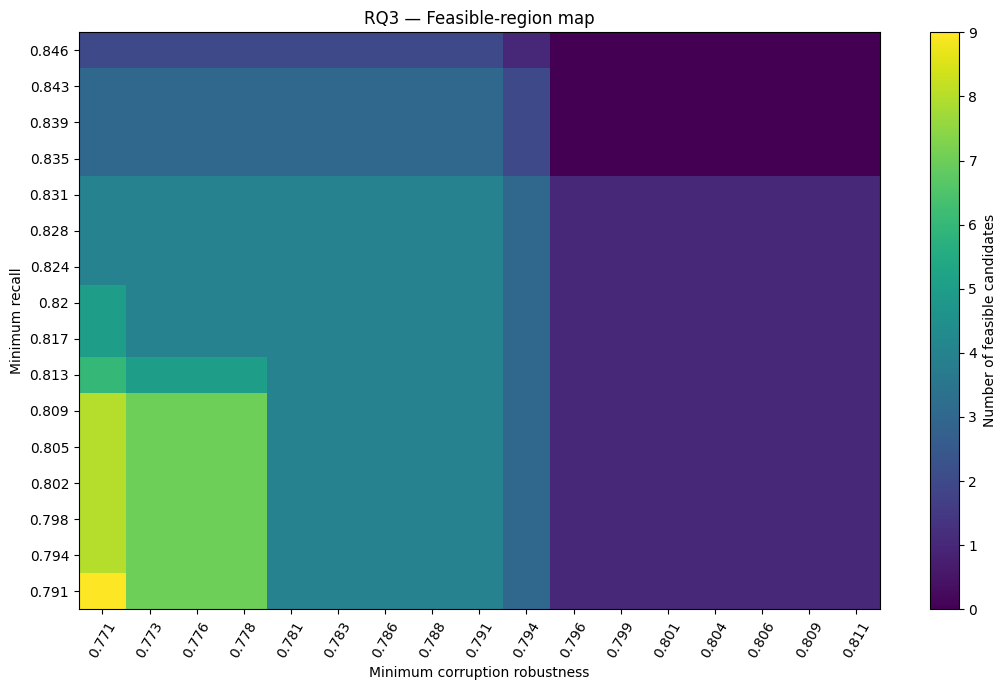

In [ ]:
# Construct robustness and recall grids
robustness_grid = np.round(
    np.linspace(
        candidate[ROBUSTNESS_COLUMN].quantile(0.10),
        candidate[ROBUSTNESS_COLUMN].quantile(0.95),
        17,
    ),
    3,
)

recall_grid = np.round(
    np.linspace(
        candidate["Recall"].quantile(0.10),
        candidate["Recall"].quantile(0.95),
        16,
    ),
    3,
)

decision_map_rows = []

# Evaluate feasible region across grid
for robustness_minimum, recall_minimum in itertools.product(robustness_grid, recall_grid):

    result = epsilon_constraint_select(
        "F1",  # primary objective
        {
            ROBUSTNESS_COLUMN: (">=", float(robustness_minimum)),
            "Recall": (">=", float(recall_minimum)),
            LATENCY_COLUMN: ("<=", latency_limit),
        },
    )

    decision_map_rows.append({
        "Robustness_Min": robustness_minimum,
        "Recall_Min": recall_minimum,
        **result,
    })

decision_map = pd.DataFrame(decision_map_rows)

decision_map.to_csv(
    OUT / "07_constraint_decision_map.csv",
    index=False,
)

# Pivot feasible counts for heatmap
feasibility_pivot = (
    decision_map
    .pivot(
        index="Recall_Min",
        columns="Robustness_Min",
        values="N_Feasible",
    )
)

# Plot feasible region heatmap
plt.figure(figsize=(11, 7))

image = plt.imshow(
    feasibility_pivot.to_numpy(),
    aspect="auto",
    origin="lower",
)

plt.colorbar(image, label="Number of feasible candidates")

plt.xticks(
    range(len(feasibility_pivot.columns)),
    feasibility_pivot.columns,
    rotation=60,
)

plt.yticks(
    range(len(feasibility_pivot.index)),
    feasibility_pivot.index,
)

plt.xlabel("Minimum corruption robustness")
plt.ylabel("Minimum recall")
plt.title("RQ3 — Feasible‑Region Map")

plt.tight_layout()

plt.savefig(
    FIG / "rq3_feasible_region_map.png",
    dpi=300,
)

plt.show()

## RQ3 — Preference Sensitivity & Opportunity Cost

This section evaluates how sensitive the TOPSIS deployment recommendation is to changes in preference weights and quantifies the opportunity cost of the selected candidate.

#### Preference Sensitivity
To test robustness of the TOPSIS selection:
- 5,000 random preference weight vectors are sampled from a Dirichlet distribution.
- Each weight vector represents a different deployment preference profile.
- TOPSIS is applied to the constrained Pareto set for each weight vector.
- The frequency with which each variant becomes the winner is recorded.

This reveals whether the selected candidate is stable across diverse preference profiles.

#### Opportunity Cost
For the final selected candidate:
- The best feasible value for each objective is identified.
- The difference between the selected candidate and the best feasible value is computed.
- Both absolute and percentage opportunity costs are reported.

This quantifies what is “given up” in each objective when selecting the compromise candidate.

So, these analyses complete RQ3 by evaluating preference robustness and trade‑offs.


In [ ]:
# Preference sensitivity (only if Pareto set exists)
if len(constrained_pareto):

    rng = np.random.default_rng(20260803)

    preference_rows = []

    # Sample 5,000 random preference weight vectors
    random_weights = rng.dirichlet(
        np.ones(len(OBJECTIVES)),
        size=5000,
    )

    for sample_index, weight_vector in enumerate(random_weights):

        # Convert sampled weights into dictionary
        sampled_weights = dict(zip(OBJECTIVES, weight_vector))

        # Apply TOPSIS to constrained Pareto set
        winner_row, ranking_table = minmax_topsis(
            constrained_pareto,
            sampled_weights,
            OBJECTIVES,
        )

        # Runner‑up (if available)
        runner_up_row = (
            ranking_table.iloc[1]
            if len(ranking_table) > 1
            else winner_row
        )

        # Store preference sensitivity result
        preference_row = {
            "Sample": sample_index,
            "Winner": winner_row["Variant"],
            "Winner_Closeness": winner_row["TOPSIS_Closeness"],
            "Runner_Up": runner_up_row["Variant"],
            "Runner_Up_Closeness": runner_up_row["TOPSIS_Closeness"],
            "Closeness_Margin": (
                winner_row["TOPSIS_Closeness"]
                - runner_up_row["TOPSIS_Closeness"]
            ),
            "N_Feasible": len(feasible_candidates),
            "N_Pareto": len(constrained_pareto),
        }

        # Store sampled weights for interpretability
        for objective, weight in sampled_weights.items():
            preference_row[f"Weight_{objective}"] = float(weight)

        preference_rows.append(preference_row)

    # Convert to DataFrame
    preference_samples = pd.DataFrame(preference_rows)

    # Winner frequency across 5,000 preference profiles
    preference_frequency = (
        preference_samples["Winner"]
        .value_counts(normalize=True)
        .rename_axis("Variant")
        .reset_index(name="Selection_Frequency")
    )

    # Save outputs
    preference_samples.to_csv(
        OUT / "08_preference_sensitivity_samples.csv",
        index=False,
    )

    preference_frequency.to_csv(
        OUT / "08b_preference_selection_frequency.csv",
        index=False,
    )

    display(preference_frequency)

else:
    preference_samples = pd.DataFrame()
    preference_frequency = pd.DataFrame()
    print("No constrained Pareto set was available for preference sensitivity.")

,Variant,Selection_Frequency
0,XGBoost | class_weight | isotonic,0.7696
1,Random Forest | class_weight | isotonic,0.1170
2,Random Forest | class_weight | platt,0.1134


In [ ]:
# Opportunity cost analysis
opportunity_cost_rows = []

if selected_candidate is not None:

    for column, direction in OBJECTIVES.items():

        # Best feasible value for this objective
        if direction == "max":
            best_feasible_value = constrained_pareto[column].max()
            selected_value = selected_candidate[column]
            absolute_cost = best_feasible_value - selected_value

        else:  # direction == "min"
            best_feasible_value = constrained_pareto[column].min()
            selected_value = selected_candidate[column]
            absolute_cost = selected_value - best_feasible_value

        # Relative opportunity cost (%)
        relative_cost_percent = (
            absolute_cost
            / max(abs(best_feasible_value), 1e-12)
            * 100
        )

        opportunity_cost_rows.append({
            "Objective": column,
            "Direction": direction,
            "Selected_Value": float(selected_value),
            "Best_Feasible_Value": float(best_feasible_value),
            "Absolute_Opportunity_Cost": float(absolute_cost),
            "Relative_Opportunity_Cost_Percent": float(relative_cost_percent),
        })

# Convert to DataFrame
opportunity_cost = pd.DataFrame(opportunity_cost_rows)

# Save opportunity cost table
opportunity_cost.to_csv(
    OUT / "09_opportunity_cost.csv",
    index=False,
)

display(opportunity_cost)

,Objective,Direction,Selected_Value,Best_Feasible_Value,Absolute_Opportunity_Cost,Relative_Opportunity_Cost_Percent
0,F1,max,0.654247,0.654247,0.000000,0.000000
1,Composite_Corruption_Robustness_Mean,max,0.779660,0.794893,0.015233,1.916311
2,Operational_Cost,min,131.950000,131.950000,0.000000,0.000000
3,Single_Sample_Latency_Median_ms,min,5.851255,5.851255,0.000000,0.000000


## Operational‑Penalty Sensitivity

This section evaluates how sensitive the operational‑cost ranking is to changes in the assumed false‑negative penalty.

The default operational penalty uses:
- FP penalty = 1  
- FN penalty = 10  

However, different deployments may assign different importance to false negatives. To test sensitivity:

1. Recalculate operational penalty for FN penalty ratios:  
   **2, 5, 10, 20, 50**

2. For each FN penalty:
   - Recompute operational cost for every seed.
   - Aggregate mean and standard deviation per variant.
   - Identify the best (lowest‑penalty) variant.
   - Record full ranking under that penalty.

This analysis shows whether the operational‑cost winner is stable across different penalty assumptions and how rankings shift under alternative operational priorities.


In [ ]:
FN_PENALTY_RATIOS = [2, 5, 10, 20, 50]

penalty_sensitivity_rows = []
penalty_variant_rows = []

# Recalculate operational penalty for each FN penalty ratio
for fn_penalty in FN_PENALTY_RATIOS:

    # Recalculate operational penalty per seed
    recalculated = clean.assign(
        Recalculated_Operational_Penalty=(
            FP_PENALTY * clean["FP"]
            + fn_penalty * clean["FN"]
        )
    )

    # Aggregate mean and std per variant
    penalty_by_variant = (
        recalculated
        .groupby("Variant", as_index=False)
        .agg(
            Mean_Operational_Penalty=("Recalculated_Operational_Penalty", "mean"),
            Std_Operational_Penalty=("Recalculated_Operational_Penalty", "std"),
        )
        .sort_values("Mean_Operational_Penalty")
    )

    # Best variant under this penalty ratio
    best_variant = penalty_by_variant.iloc[0]

    penalty_sensitivity_rows.append({
        "FP_Penalty": FP_PENALTY,
        "FN_Penalty": fn_penalty,
        "Best_Variant_By_Penalty": best_variant["Variant"],
        "Lowest_Mean_Penalty": float(best_variant["Mean_Operational_Penalty"]),
    })

    # Store full ranking table for this penalty ratio
    for _, row in penalty_by_variant.iterrows():
        penalty_variant_rows.append({
            "FP_Penalty": FP_PENALTY,
            "FN_Penalty": fn_penalty,
            "Variant": row["Variant"],
            "Mean_Operational_Penalty": float(row["Mean_Operational_Penalty"]),
            "Std_Operational_Penalty": float(row["Std_Operational_Penalty"]),
        })

# Convert to DataFrames
penalty_sensitivity = pd.DataFrame(penalty_sensitivity_rows)
penalty_variant_summary = pd.DataFrame(penalty_variant_rows)

# Save outputs
penalty_sensitivity.to_csv(
    OUT / "10_operational_penalty_sensitivity_summary.csv",
    index=False,
)

penalty_variant_summary.to_csv(
    OUT / "10b_operational_penalty_by_variant.csv",
    index=False,
)

# Display summary
display(penalty_sensitivity)

,FP_Penalty,FN_Penalty,Best_Variant_By_Penalty,Lowest_Mean_Penalty
0,1.0,2,XGBoost | none | isotonic,50.75
1,1.0,5,XGBoost | none | isotonic,77.30
2,1.0,10,XGBoost | none | isotonic,121.55
3,1.0,20,XGBoost | none | isotonic,210.05
4,1.0,50,Random Forest | class_weight | isotonic,445.05


## Notebook 3 Summary

In [ ]:
methodological_report = {
    # RQ1 - Dimension-level ranking influence
    "RQ1_Most_Influential_Dimension_By_Mean_Absolute_Rank_Change": (
        None
        if dimension_influence_summary.empty
        else dimension_influence_summary.iloc[0]["Omitted_Dimension"]
    ),

    # RQ2 - Robustness stability
    "RQ2_Full_Protocol_Winner": full_protocol_winner,

    "RQ2_Leave_One_Condition_Out_Winner_Change_Count": int(
        leave_one_out_df["Winner_Changed"].sum()
    ),

    "RQ2_Most_Frequent_Winner_Under_Random_Condition_Weights": (
        None
        if weight_selection_frequency.empty
        else weight_selection_frequency.iloc[0]["Variant"]
    ),

    "RQ2_Most_Frequent_Winner_Selection_Frequency": (
        None
        if weight_selection_frequency.empty
        else float(weight_selection_frequency.iloc[0]["Selection_Frequency"])
    ),

    # RQ3 — Constraint-aware selection
    "RQ3_Number_of_Feasible_Candidates": len(feasible_candidates),

    "RQ3_Number_of_Constrained_Pareto_Candidates": len(constrained_pareto),

    "RQ3_Selected_Candidate": (
        None
        if selected_candidate is None
        else selected_candidate["Variant"]
    ),

    "RQ3_Selection_Method": (
        "Experimental constraints followed by "
        "Pareto filtering and adapted min-max TOPSIS."
    ),

    # Interpretation boundaries
    "Constraint_Status": (
        "Experimental parameter values derived from observed candidate ranges; "
        "not industrial requirements."
    ),

    "Operational_Penalty_Status": (
        "Assumed asymmetric penalty; sensitivity tested for FN penalties "
        "2, 5, 10, 20 and 50."
    ),

    "Robustness_Score_Status": (
        "Adapted secondary composite summary; condition-level retention "
        "remains primary."
    ),
}

# Save JSON report
with open(OUT / "11_methodological_report.json", "w", encoding="utf-8") as file:
    json.dump(methodological_report, file, indent=2)

display(
    pd.DataFrame({
        "Item": list(methodological_report.keys()),
        "Value": [str(value) for value in methodological_report.values()],
    })
)

,Item,Value
0,RQ1_Most_Influential_Dimension_By_Mean_Absolut...,Reliability
1,RQ2_Full_Protocol_Winner,Random Forest | smote | isotonic
2,RQ2_Leave_One_Condition_Out_Winner_Change_Count,1
3,RQ2_Most_Frequent_Winner_Under_Random_Conditio...,Random Forest | smote | isotonic
4,RQ2_Most_Frequent_Winner_Selection_Frequency,0.8556
5,RQ3_Number_of_Feasible_Candidates,4
6,RQ3_Number_of_Constrained_Pareto_Candidates,4
7,RQ3_Selected_Candidate,XGBoost | class_weight | isotonic
8,RQ3_Selection_Method,Experimental constraints followed by Pareto fi...
9,Constraint_Status,Experimental parameter values derived from obs...


## Final interpretation

This notebook provides the main methodological evidence for the revised research questions:

- **RQ1:** identifies which evaluation dimensions influence deployment-oriented rankings;
- **RQ2:** tests whether the adapted robustness conclusion is sensitive to corruption inclusion, corruption weights and severity protocols;
- **RQ3:** implements a complete deployment-selection process using feasibility constraints, Pareto filtering, preference-aware compromise selection, sensitivity analysis and opportunity-cost reporting.

The notebook does not claim that its experimental constraints represent a real industrial deployment. They validate whether the proposed decision method behaves transparently under changing requirements and preferences.